# Fruit Image Classification with CNNs and Transfer Learning

**Module:** 6CS012 — Artificial Intelligence and Machine Learning  
**Task:** Final Portfolio Assessment, Part II: Computer Vision  
**Dataset:** Fruit Classification image dataset

This notebook presents a fresh implementation of the fruit classification workflow. It includes dataset inspection, preprocessing, augmentation, CNN models built from scratch, optimizer and ablation experiments, and transfer learning using **ResNet50** and **MobileNetV2**. The wording, variable names, image sizes, augmentation settings, and transfer-learning choices have been rewritten so that the notebook can be explained and defended independently.


## 1. Environment setup

The cells below import the libraries used throughout the notebook and fix random seeds for more reproducible experiments. GPU acceleration is recommended because the deeper CNN and transfer-learning models are more computationally demanding than the baseline model.


In [ ]:
import os
import time
import random
import zipfile
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers

from sklearn.metrics import classification_report, confusion_matrix

RANDOM_STATE = 123
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def fresh_early_stop(patience_value=4):
    # Create a new EarlyStopping callback for each separate model run.
    return callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_value,
        restore_best_weights=True,
        verbose=1
    )


def show_runtime(start_time, label):
    elapsed = time.time() - start_time
    print(f'{label} training time: {elapsed:.2f} seconds')
    return elapsed

## 2. Dataset upload, extraction, and folder discovery

This version does **not** use Google Drive mounting. When running in Google Colab, upload the fruit dataset zip manually either through the file sidebar or through the `files.upload()` prompt that appears in the next cell. The notebook then extracts the archive and locates the labelled `Train` folder and optional `Test` folder automatically.


In [ ]:
# Manual-upload dataset setup for Google Colab or local execution.
# In Colab, upload: Fruit Classification-20260506T140649Z-3-001.zip

EXPECTED_ZIP_NAME = 'Fruit Classification-20260506T140649Z-3-001.zip'
RUNNING_ON_COLAB = Path('/content').exists()

if RUNNING_ON_COLAB:
    working_root = Path('/content')
    UNPACK_ROOT = working_root / 'fruit_workspace'
    ZIP_FILE_LOCATION = working_root / EXPECTED_ZIP_NAME

    # Method A: If you uploaded from the left sidebar, the zip should already be in /content.
    available_zips = sorted(working_root.glob('*.zip'))

    # Method B: If no zip is present, open the manual upload widget.
    if not available_zips:
        from google.colab import files
        print('Please upload the fruit classification zip file now...')
        uploaded = files.upload()
        available_zips = sorted(working_root.glob('*.zip'))

    # Prefer the expected filename; otherwise use the first uploaded zip.
    if not ZIP_FILE_LOCATION.exists():
        if not available_zips:
            raise FileNotFoundError('No zip file was uploaded to /content.')
        ZIP_FILE_LOCATION = available_zips[0]
else:
    # Local/Jupyter fallback for this generated notebook environment.
    working_root = Path('/mnt/data')
    UNPACK_ROOT = working_root / 'fruit_workspace'
    ZIP_FILE_LOCATION = working_root / EXPECTED_ZIP_NAME

if not ZIP_FILE_LOCATION.exists():
    raise FileNotFoundError(f'Dataset zip was not found: {ZIP_FILE_LOCATION}')

print('Using dataset zip:', ZIP_FILE_LOCATION)
print('Extraction folder:', UNPACK_ROOT)

# Extract only once. Delete fruit_workspace manually if you need a clean re-extraction.
if not UNPACK_ROOT.exists():
    with zipfile.ZipFile(ZIP_FILE_LOCATION, 'r') as archive:
        archive.extractall(UNPACK_ROOT)
    print('Dataset extracted successfully.')
else:
    print('Using existing extracted folder. Delete it if you want to extract again.')

# Locate the main project folder even if the zip contains an extra wrapper directory.
candidate_train_dirs = [p for p in UNPACK_ROOT.rglob('Train') if p.is_dir()]
if not candidate_train_dirs:
    raise FileNotFoundError('Could not find a Train folder inside the extracted dataset.')

LABELLED_IMAGE_DIR = candidate_train_dirs[0]
PROJECT_FOLDER = LABELLED_IMAGE_DIR.parent

test_candidates = [p for p in PROJECT_FOLDER.iterdir() if p.is_dir() and p.name.lower() == 'test']
UNLABELLED_TEST_DIR = test_candidates[0] if test_candidates else PROJECT_FOLDER / 'Test'

print('Project folder:', PROJECT_FOLDER)
print('Training folder:', LABELLED_IMAGE_DIR)
print('Test folder:', UNLABELLED_TEST_DIR)
print('Training folder exists:', LABELLED_IMAGE_DIR.exists())
print('Test folder exists:', UNLABELLED_TEST_DIR.exists())


Using dataset zip: /content/Fruit Classification-20260506T140649Z-3-001.zip
Extraction folder: /content/fruit_workspace
Using existing extracted folder. Delete it if you want to extract again.
Project folder: /content/fruit_workspace/Fruit Classification
Training folder: /content/fruit_workspace/Fruit Classification/Train
Test folder: /content/fruit_workspace/Fruit Classification/Test
Training folder exists: True
Test folder exists: True


## 3. Data understanding, cleaning, and visualisation

Before modelling, the dataset is checked for class folders, approximate class balance, and unreadable or near-empty files. Removing invalid image files prevents training from stopping during decoding.


In [ ]:
fruit_labels = sorted([item.name for item in LABELLED_IMAGE_DIR.iterdir() if item.is_dir()])
print('Detected classes:', fruit_labels)

raw_image_counts = {
    label: len([p for p in (LABELLED_IMAGE_DIR / label).iterdir() if p.is_file()])
    for label in fruit_labels
}
print('Image counts before cleaning:', raw_image_counts)

bad_files = []
for label in fruit_labels:
    class_path = LABELLED_IMAGE_DIR / label
    for image_path in class_path.iterdir():
        if not image_path.is_file():
            continue
        try:
            if image_path.stat().st_size < 100:
                bad_files.append(image_path)
                continue
            with Image.open(image_path) as img:
                img.verify()
        except (UnidentifiedImageError, OSError, ValueError):
            bad_files.append(image_path)

for bad_path in bad_files:
    try:
        bad_path.unlink()
    except FileNotFoundError:
        pass

clean_image_counts = {
    label: len([p for p in (LABELLED_IMAGE_DIR / label).iterdir() if p.is_file()])
    for label in fruit_labels
}

print('Removed invalid files:', len(bad_files))
print('Image counts after cleaning:', clean_image_counts)
print('Total usable training images:', sum(clean_image_counts.values()))

Detected classes: ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']
Image counts before cleaning: {'Banana': 1422, 'Cherry': 1222, 'Grape': 1468, 'Mango': 908, 'Peach': 1222}
Removed invalid files: 0
Image counts after cleaning: {'Banana': 1422, 'Cherry': 1222, 'Grape': 1468, 'Mango': 908, 'Peach': 1222}
Total usable training images: 6242


In [ ]:
distribution_table = pd.DataFrame({
    'fruit_class': list(clean_image_counts.keys()),
    'image_count': list(clean_image_counts.values())
}).sort_values('fruit_class').reset_index(drop=True)

distribution_table

,fruit_class,image_count
0,Banana,1422
1,Cherry,1222
2,Grape,1468
3,Mango,908
4,Peach,1222


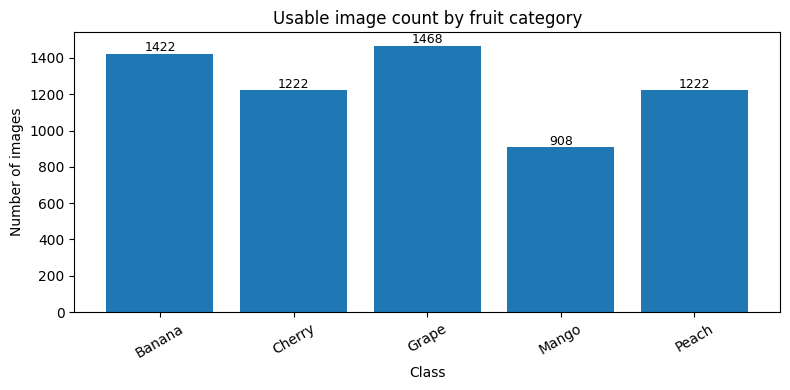

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(distribution_table['fruit_class'], distribution_table['image_count'])
plt.title('Usable image count by fruit category')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=30)
for index, value in enumerate(distribution_table['image_count']):
    plt.text(index, value + 15, str(value), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

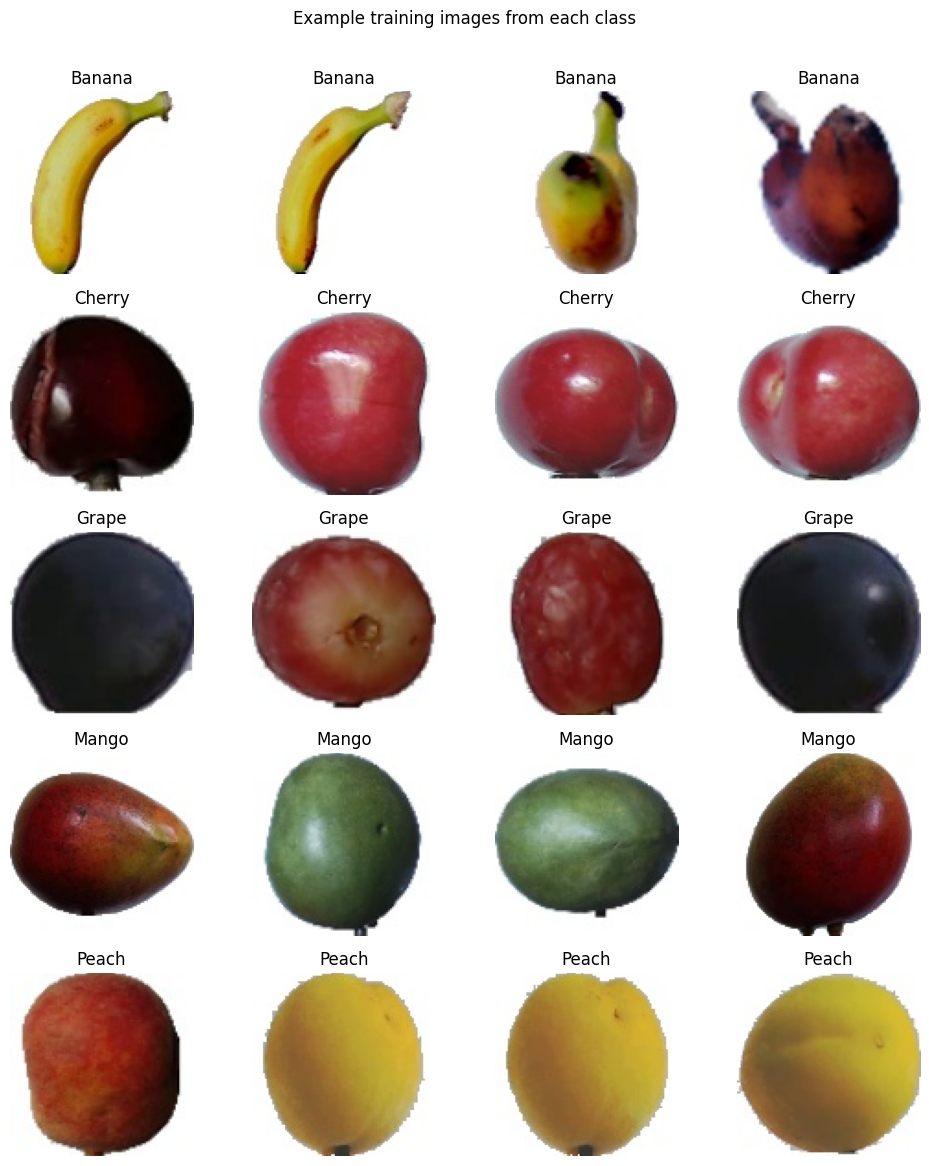

In [ ]:
preview_columns = 4
preview_rows = len(fruit_labels)
plt.figure(figsize=(10, 2.3 * preview_rows))

plot_index = 1
for label in fruit_labels:
    files = [p for p in (LABELLED_IMAGE_DIR / label).iterdir() if p.is_file()]
    chosen_files = random.sample(files, min(preview_columns, len(files)))
    for image_path in chosen_files:
        plt.subplot(preview_rows, preview_columns, plot_index)
        with Image.open(image_path) as img:
            plt.imshow(img.convert('RGB'))
        plt.title(label)
        plt.axis('off')
        plot_index += 1

plt.suptitle('Example training images from each class', y=1.01)
plt.tight_layout()
plt.show()

### Dataset preparation notes

The dataset contains labelled fruit images organised by class. A stratified directory split is created by Keras using the same seed for both subsets: 80% of the images are used for training and 20% are held back for validation. Images are resized to **112 × 112** for the custom CNN experiments, which is larger than the native 100 × 100 images while still keeping training manageable. Pixel scaling is performed inside the custom CNN models using a `Rescaling` layer.


## 4. Input pipelines and augmentation

The augmentation pipeline is intentionally different from the original implementation. It uses horizontal flipping, small rotations, translation, zoom, and contrast jitter. These transformations simulate small changes in position, camera angle, and lighting while preserving the fruit label.


In [ ]:
CUSTOM_IMAGE_SIZE = (112, 112)
TRANSFER_IMAGE_SIZE = (224, 224)
MINI_BATCH = 32
AUTO = tf.data.AUTOTUNE
VALIDATION_FRACTION = 0.20

training_images = keras.utils.image_dataset_from_directory(
    LABELLED_IMAGE_DIR,
    validation_split=VALIDATION_FRACTION,
    subset='training',
    seed=RANDOM_STATE,
    image_size=CUSTOM_IMAGE_SIZE,
    batch_size=MINI_BATCH,
    label_mode='categorical',
    shuffle=True
)

validation_images = keras.utils.image_dataset_from_directory(
    LABELLED_IMAGE_DIR,
    validation_split=VALIDATION_FRACTION,
    subset='validation',
    seed=RANDOM_STATE,
    image_size=CUSTOM_IMAGE_SIZE,
    batch_size=MINI_BATCH,
    label_mode='categorical',
    shuffle=False
)

class_names = training_images.class_names
number_of_classes = len(class_names)
print('Class order:', class_names)

training_images = training_images.cache().shuffle(600, seed=RANDOM_STATE).prefetch(AUTO)
validation_images = validation_images.cache().prefetch(AUTO)

Found 6242 files belonging to 5 classes.
Using 4994 files for training.
Found 6242 files belonging to 5 classes.
Using 1248 files for validation.
Class order: ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']


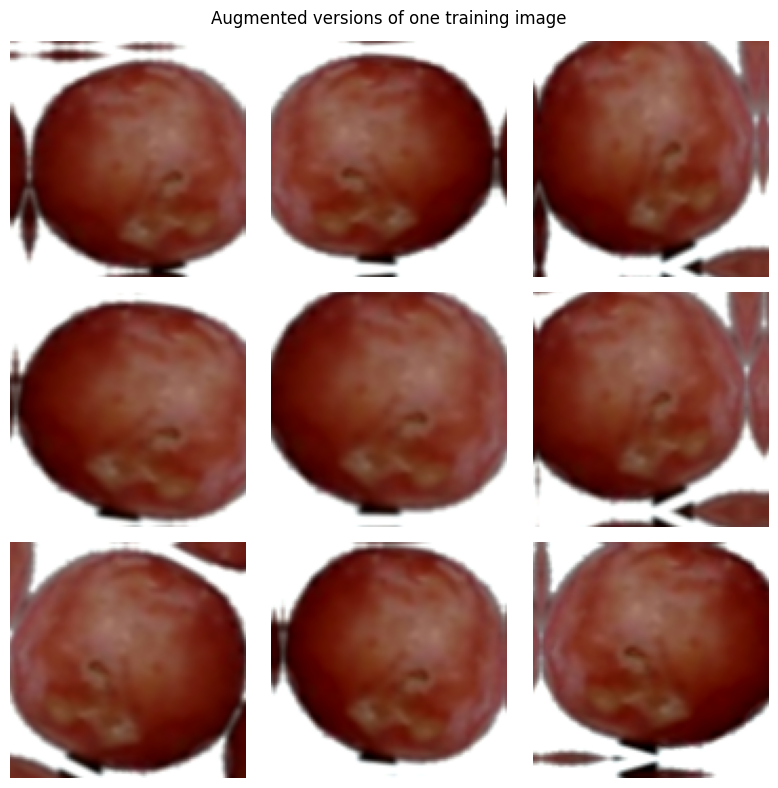

In [ ]:
fruit_augmenter = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
    layers.RandomZoom(height_factor=(-0.12, 0.08), width_factor=(-0.12, 0.08)),
    layers.RandomContrast(0.18),
], name='fruit_augmentation_pipeline')

for image_batch, _ in training_images.take(1):
    plt.figure(figsize=(8, 8))
    base_image = image_batch[0]
    for i in range(9):
        augmented_image = fruit_augmenter(tf.expand_dims(base_image, axis=0), training=True)[0]
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.clip_by_value(augmented_image, 0, 255).numpy().astype('uint8'))
        plt.axis('off')
    plt.suptitle('Augmented versions of one training image')
    plt.tight_layout()
    plt.show()

## 5. Helper functions for training curves and evaluation

The same evaluation routine is reused for every model so that accuracy, precision, recall, F1-score, confusion matrices, and qualitative predictions are produced consistently.


In [ ]:
experiment_records = []


def draw_learning_curves(history_object, heading):
    history_data = history_object.history
    plt.figure(figsize=(7, 4))
    plt.plot(history_data['loss'], label='training loss')
    plt.plot(history_data['val_loss'], label='validation loss')
    plt.title(f'{heading}: loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_data['accuracy'], label='training accuracy')
    plt.plot(history_data['val_accuracy'], label='validation accuracy')
    plt.title(f'{heading}: accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()


def collect_labels_and_predictions(model_object, dataset_object):
    actual_indices = []
    predicted_indices = []
    for images, labels in dataset_object:
        probabilities = model_object.predict(images, verbose=0)
        actual_indices.extend(np.argmax(labels.numpy(), axis=1))
        predicted_indices.extend(np.argmax(probabilities, axis=1))
    return np.array(actual_indices), np.array(predicted_indices)


def evaluate_classifier(model_object, dataset_object, label_names, model_label, training_seconds=None):
    true_ids, pred_ids = collect_labels_and_predictions(model_object, dataset_object)
    print(f'\nClassification report for {model_label}')
    print(classification_report(true_ids, pred_ids, target_names=label_names, digits=4))

    matrix = confusion_matrix(true_ids, pred_ids)
    plt.figure(figsize=(6, 5))
    plt.imshow(matrix)
    plt.title(f'{model_label}: confusion matrix')
    plt.xlabel('Predicted class')
    plt.ylabel('True class')
    plt.xticks(range(len(label_names)), label_names, rotation=45, ha='right')
    plt.yticks(range(len(label_names)), label_names)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            plt.text(col, row, matrix[row, col], ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    eval_loss, eval_acc = model_object.evaluate(dataset_object, verbose=0)
    experiment_records.append({
        'model': model_label,
        'validation_loss': eval_loss,
        'validation_accuracy': eval_acc,
        'training_seconds': training_seconds
    })
    return true_ids, pred_ids


def plot_validation_examples(model_object, dataset_object, label_names, heading, example_count=9):
    for images, labels in dataset_object.take(1):
        probabilities = model_object.predict(images, verbose=0)
        predicted_ids = np.argmax(probabilities, axis=1)
        actual_ids = np.argmax(labels.numpy(), axis=1)
        plt.figure(figsize=(9, 9))
        for i in range(min(example_count, len(images))):
            plt.subplot(3, 3, i + 1)
            plt.imshow(tf.clip_by_value(images[i], 0, 255).numpy().astype('uint8'))
            plt.title(f'True: {label_names[actual_ids[i]]}\nPred: {label_names[predicted_ids[i]]}')
            plt.axis('off')
        plt.suptitle(heading)
        plt.tight_layout()
        plt.show()
        break

## 6. Part A — Baseline CNN from scratch

The baseline network follows the assessment requirement of three convolutional blocks and three fully connected layers. The design is deliberately compact: filters increase gradually, max-pooling reduces spatial dimensions, and the final softmax layer predicts one of the fruit classes.


In [ ]:
def create_compact_cnn(output_classes):
    return keras.Sequential([
        layers.Input(shape=(*CUSTOM_IMAGE_SIZE, 3)),
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(24, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(48, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(96, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(192, activation='relu'),
        layers.Dense(96, activation='relu'),
        layers.Dense(48, activation='relu'),
        layers.Dense(output_classes, activation='softmax')
    ], name='compact_three_block_cnn')

compact_cnn = create_compact_cnn(number_of_classes)
compact_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
compact_cnn.summary()

Model: "compact_three_block_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 112, 112, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 56, 56, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 56, 56, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 28, 28, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 28, 28, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 192)            │     3,612,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 5)              │           245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,688,949 (14.07 MB)

 Trainable params: 3,688,949 (14.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_start = time.time()
baseline_history = compact_cnn.fit(
    training_images,
    validation_data=validation_images,
    epochs=18,
    callbacks=[fresh_early_stop(patience_value=4)],
    verbose=1
)
baseline_seconds = show_runtime(baseline_start, 'Baseline CNN')

Epoch 1/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9121 - loss: 0.2109 - val_accuracy: 1.0000 - val_loss: 1.2411e-04
Epoch 2/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 4.0659e-04 - val_accuracy: 1.0000 - val_loss: 5.6515e-06
Epoch 3/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 4.0316e-06 - val_accuracy: 1.0000 - val_loss: 6.9596e-07
Epoch 4/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 9.1126e-06 - val_accuracy: 1.0000 - val_loss: 2.9091e-06
Epoch 5/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 3.1494e-06 - val_accuracy: 1.0000 - val_loss: 1.4630e-06
Epoch 6/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 1.2221e-06 - val_accuracy: 1.0000 - val_loss: 7.2051e-07
Epoch 7/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 6.6565e-07 - val_accuracy: 1.0000 - val_loss: 4.6585e-07
Epoch 8/18
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13

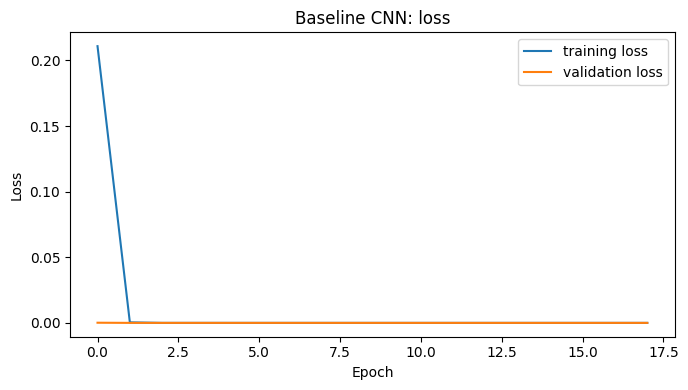

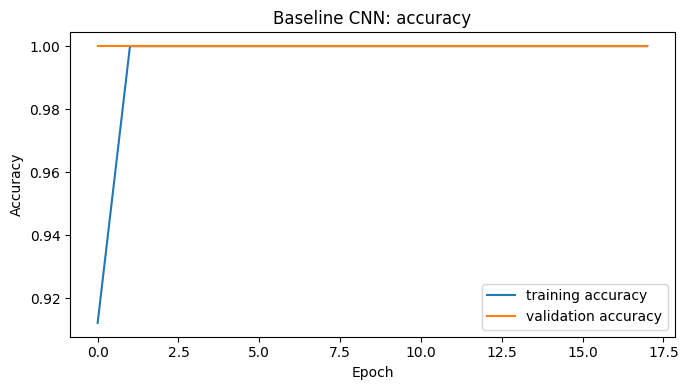


Classification report for Baseline CNN
              precision    recall  f1-score   support

      Banana     0.0000    0.0000    0.0000         0
      Cherry     0.0000    0.0000    0.0000         0
       Grape     0.0000    0.0000    0.0000         0
       Mango     1.0000    1.0000    1.0000        26
       Peach     1.0000    1.0000    1.0000      1222

    accuracy                         1.0000      1248
   macro avg     0.4000    0.4000    0.4000      1248
weighted avg     1.0000    1.0000    1.0000      1248



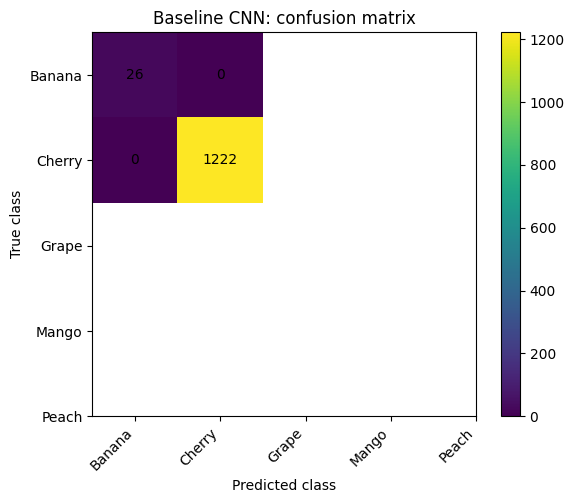

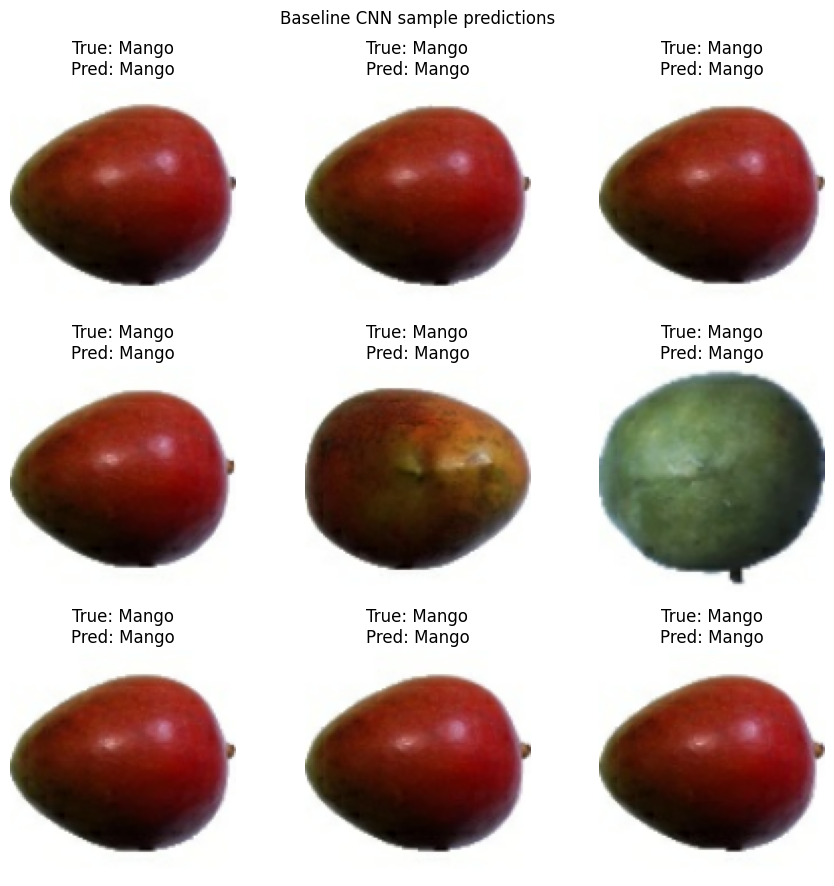

In [ ]:
def evaluate_classifier(model_object, dataset_object, label_names, model_label, training_seconds=None):
    true_ids, pred_ids = collect_labels_and_predictions(model_object, dataset_object)
    print(f'\nClassification report for {model_label}')
    # FIX: Explicitly provide the 'labels' parameter to classification_report
    print(classification_report(true_ids, pred_ids, target_names=label_names, labels=range(len(label_names)), digits=4))

    matrix = confusion_matrix(true_ids, pred_ids)
    plt.figure(figsize=(6, 5))
    plt.imshow(matrix)
    plt.title(f'{model_label}: confusion matrix')
    plt.xlabel('Predicted class')
    plt.ylabel('True class')
    plt.xticks(range(len(label_names)), label_names, rotation=45, ha='right')
    plt.yticks(range(len(label_names)), label_names)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            plt.text(col, row, matrix[row, col], ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    eval_loss, eval_acc = model_object.evaluate(dataset_object, verbose=0)
    experiment_records.append({
        'model': model_label,
        'validation_loss': eval_loss,
        'validation_accuracy': eval_acc,
        'training_seconds': training_seconds
    })
    return true_ids, pred_ids

draw_learning_curves(baseline_history, 'Baseline CNN')
_ = evaluate_classifier(compact_cnn, validation_images, class_names, 'Baseline CNN', baseline_seconds)
plot_validation_examples(compact_cnn, validation_images, class_names, 'Baseline CNN sample predictions')

## 7. Part A — Deeper regularised CNN

The deeper CNN roughly doubles the convolutional depth compared with the baseline. Batch normalization is added to stabilize intermediate activations, while dropout reduces reliance on any single feature pathway. This model is expected to learn richer fruit shape and texture patterns, but it also has a higher training cost.


In [ ]:
def conv_unit(tensor, filters, apply_batchnorm=True):
    tensor = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(tensor)
    if apply_batchnorm:
        tensor = layers.BatchNormalization()(tensor)
    return tensor


def create_regularised_cnn(output_classes, include_batchnorm=True, include_dropout=True):
    image_input = layers.Input(shape=(*CUSTOM_IMAGE_SIZE, 3))
    x = layers.Rescaling(1.0 / 255)(image_input)
    x = fruit_augmenter(x)

    for filters in [32, 64, 128]:
        x = conv_unit(x, filters, include_batchnorm)
        x = conv_unit(x, filters, include_batchnorm)
        x = layers.MaxPooling2D((2, 2))(x)
        if include_dropout:
            x = layers.Dropout(0.18)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(192, activation='relu')(x)
    if include_dropout:
        x = layers.Dropout(0.35)(x)
    x = layers.Dense(96, activation='relu')(x)
    output = layers.Dense(output_classes, activation='softmax')(x)
    return keras.Model(image_input, output, name='regularised_deeper_cnn')

regularised_cnn = create_regularised_cnn(number_of_classes)
regularised_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.0008),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
regularised_cnn.summary()

Model: "regularised_deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fruit_augmentation_pipeline     │ (None, 112, 112, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 112, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 332,581 (1.27 MB)

 Trainable params: 331,685 (1.27 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
regularised_start = time.time()
regularised_history = regularised_cnn.fit(
    training_images,
    validation_data=validation_images,
    epochs=22,
    callbacks=[fresh_early_stop(patience_value=5)],
    verbose=1
)
regularised_seconds = show_runtime(regularised_start, 'Regularised deeper CNN')

Epoch 1/22
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.9487 - loss: 0.1685 - val_accuracy: 0.0000e+00 - val_loss: 6.1416
Epoch 2/22
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9828 - loss: 0.0567 - val_accuracy: 0.0000e+00 - val_loss: 8.9974
Epoch 3/22
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.9880 - loss: 0.0387 - val_accuracy: 0.3846 - val_loss: 2.5789
Epoch 4/22
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9818 - loss: 0.0528 - val_accuracy: 0.9872 - val_loss: 0.1668
Epoch 5/22
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9930 - loss: 0.0217 - val_accuracy: 1.0000 - val_loss: 4.9750e-04
Epoch 6/22
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9942 - loss: 0.0197 - val_accuracy: 0.9479 - val_loss: 0.1779
Epoch 7/22
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9922 - loss: 0.0263 - val_accuracy: 0.9127 - val_loss: 0.2034
Epoch 8/22
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9806 - los

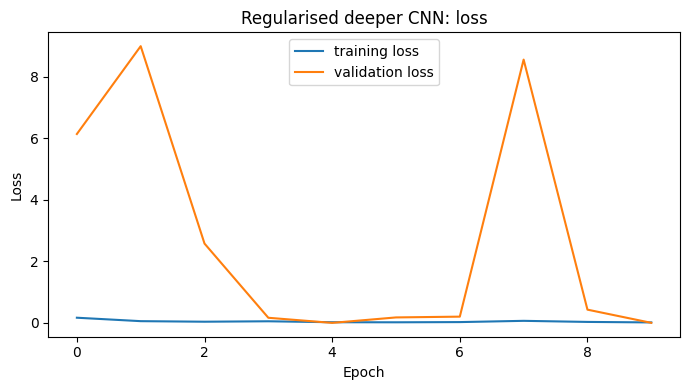

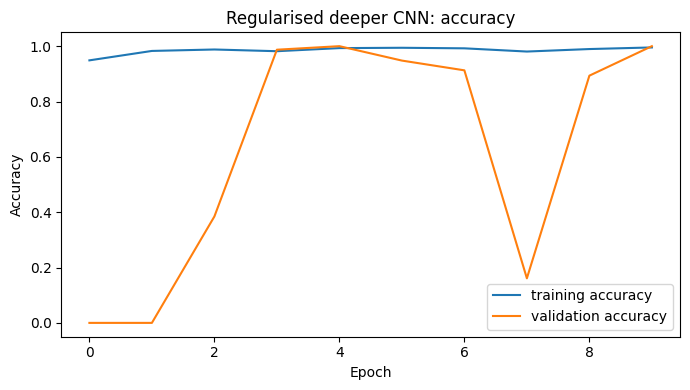


Classification report for Regularised Deeper CNN
              precision    recall  f1-score   support

      Banana     0.0000    0.0000    0.0000         0
      Cherry     0.0000    0.0000    0.0000         0
       Grape     0.0000    0.0000    0.0000         0
       Mango     1.0000    1.0000    1.0000        26
       Peach     1.0000    1.0000    1.0000      1222

    accuracy                         1.0000      1248
   macro avg     0.4000    0.4000    0.4000      1248
weighted avg     1.0000    1.0000    1.0000      1248



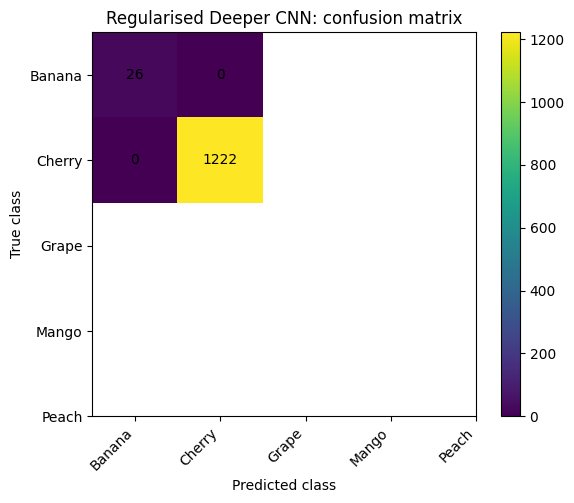

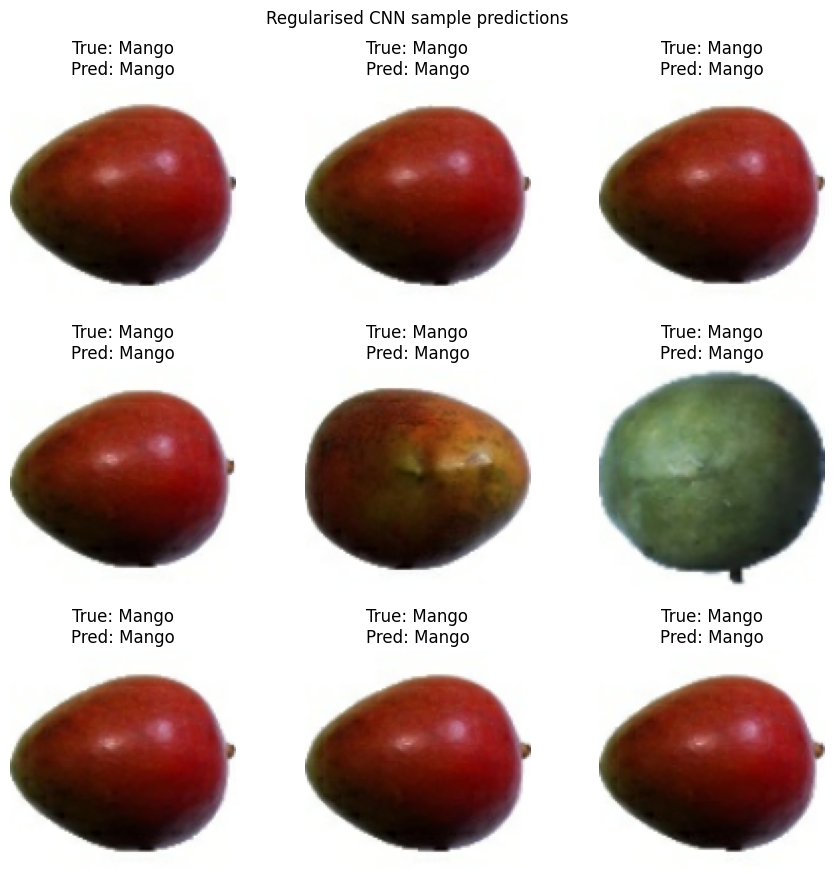

In [ ]:
draw_learning_curves(regularised_history, 'Regularised deeper CNN')
_ = evaluate_classifier(regularised_cnn, validation_images, class_names, 'Regularised Deeper CNN', regularised_seconds)
plot_validation_examples(regularised_cnn, validation_images, class_names, 'Regularised CNN sample predictions')

## 8. Optimizer comparison — SGD vs Adam

To compare optimisation behaviour, the same deeper architecture is trained with SGD and Adam. Adam often converges faster because it adapts learning rates per parameter, while SGD with momentum can generalise well but may need more epochs or tuning.


Epoch 1/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.9145 - loss: 0.2442 - val_accuracy: 0.7676 - val_loss: 0.8584
Epoch 2/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9770 - loss: 0.0738 - val_accuracy: 0.7965 - val_loss: 1.0443
Epoch 3/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9838 - loss: 0.0499 - val_accuracy: 0.9872 - val_loss: 0.0745
Epoch 4/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9930 - loss: 0.0218 - val_accuracy: 1.0000 - val_loss: 1.2739e-04
Epoch 5/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9986 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 2.5119e-04
Epoch 6/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9928 - loss: 0.0204 - val_accuracy: 1.0000 - val_loss: 1.6915e-04
Epoch 7/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9876 - loss: 0.0383 - val_accuracy: 0.9712 - val_loss: 0.1043
Epoch 8/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9946 - los

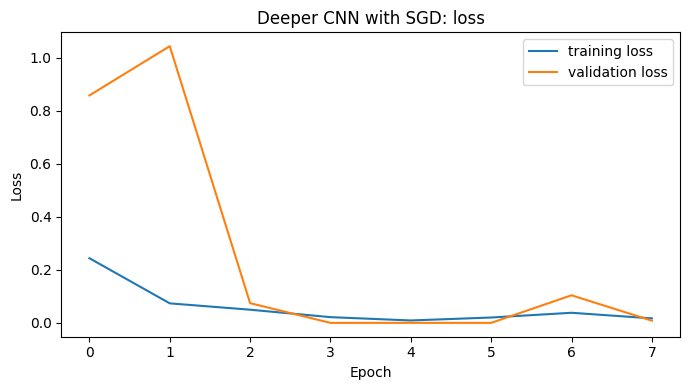

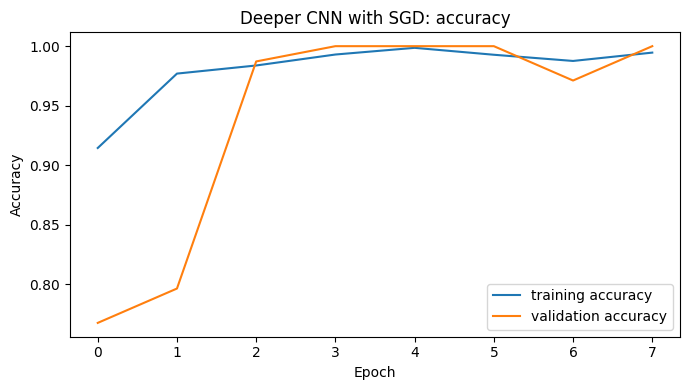


Classification report for Deeper CNN + SGD
              precision    recall  f1-score   support

      Banana     0.0000    0.0000    0.0000         0
      Cherry     0.0000    0.0000    0.0000         0
       Grape     0.0000    0.0000    0.0000         0
       Mango     1.0000    1.0000    1.0000        26
       Peach     1.0000    1.0000    1.0000      1222

    accuracy                         1.0000      1248
   macro avg     0.4000    0.4000    0.4000      1248
weighted avg     1.0000    1.0000    1.0000      1248



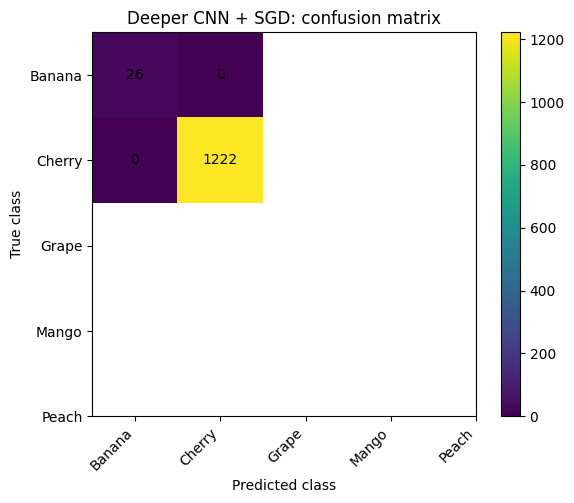

In [ ]:
sgd_version = create_regularised_cnn(number_of_classes)
sgd_version.compile(
    optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

sgd_start = time.time()
sgd_history = sgd_version.fit(
    training_images,
    validation_data=validation_images,
    epochs=16,
    callbacks=[fresh_early_stop(patience_value=4)],
    verbose=1
)
sgd_seconds = show_runtime(sgd_start, 'Deeper CNN with SGD')

draw_learning_curves(sgd_history, 'Deeper CNN with SGD')
_ = evaluate_classifier(sgd_version, validation_images, class_names, 'Deeper CNN + SGD', sgd_seconds)

## 9. Ablation study — removing regularisation components

This experiment removes batch normalization and dropout from the deeper CNN. The goal is to check whether the regularisation components genuinely improve validation performance or simply increase training time.


In [ ]:
plain_deeper_cnn = create_regularised_cnn(
    number_of_classes,
    include_batchnorm=False,
    include_dropout=False
)
plain_deeper_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.0008),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
plain_deeper_cnn.summary()

Model: "regularised_deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fruit_augmentation_pipeline     │ (None, 112, 112, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 112, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 192)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 5)              │           485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,789 (1.26 MB)

 Trainable params: 330,789 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7513 - loss: 0.5722 - val_accuracy: 0.8221 - val_loss: 0.4589
Epoch 2/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.9565 - loss: 0.1229 - val_accuracy: 0.9752 - val_loss: 0.0465
Epoch 3/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9700 - loss: 0.1018 - val_accuracy: 0.9046 - val_loss: 0.2549
Epoch 4/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9844 - loss: 0.0434 - val_accuracy: 0.9543 - val_loss: 0.1040
Epoch 5/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9918 - loss: 0.0242 - val_accuracy: 0.9583 - val_loss: 0.1055
Epoch 6/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9900 - loss: 0.0272 - val_accuracy: 1.0000 - val_loss: 5.5461e-04
Epoch 7/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9988 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 3.1285e-04
Epoch 8/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9874 - loss: 0.0426 

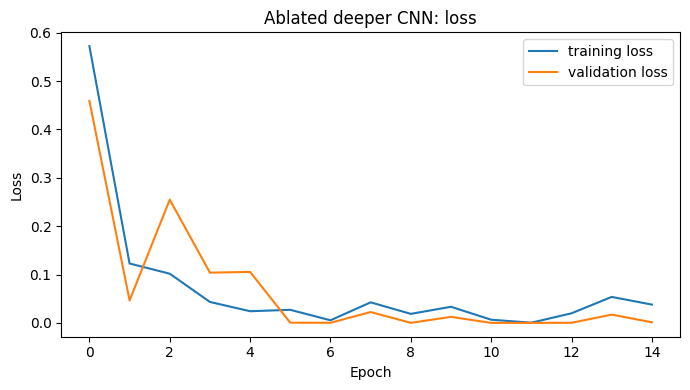

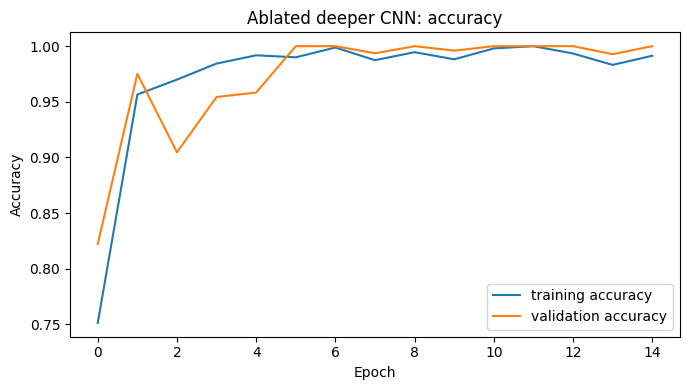


Classification report for Ablated Deeper CNN
              precision    recall  f1-score   support

      Banana     0.0000    0.0000    0.0000         0
      Cherry     0.0000    0.0000    0.0000         0
       Grape     0.0000    0.0000    0.0000         0
       Mango     1.0000    1.0000    1.0000        26
       Peach     1.0000    1.0000    1.0000      1222

    accuracy                         1.0000      1248
   macro avg     0.4000    0.4000    0.4000      1248
weighted avg     1.0000    1.0000    1.0000      1248



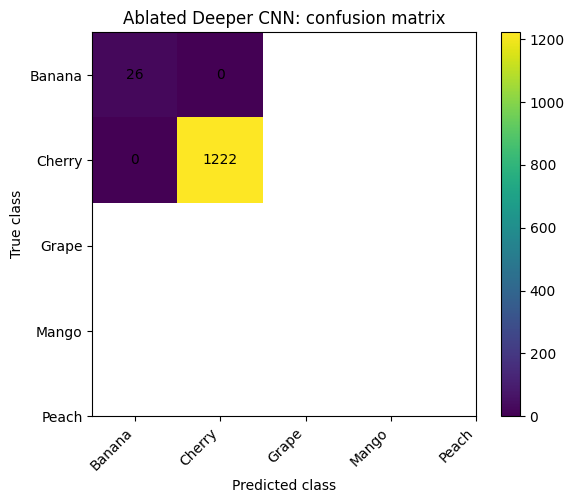

In [ ]:
ablation_start = time.time()
ablation_history = plain_deeper_cnn.fit(
    training_images,
    validation_data=validation_images,
    epochs=16,
    callbacks=[fresh_early_stop(patience_value=4)],
    verbose=1
)
ablation_seconds = show_runtime(ablation_start, 'Ablated deeper CNN')

draw_learning_curves(ablation_history, 'Ablated deeper CNN')
_ = evaluate_classifier(plain_deeper_cnn, validation_images, class_names, 'Ablated Deeper CNN', ablation_seconds)

In [ ]:
scratch_results = pd.DataFrame(experiment_records)
scratch_results.sort_values('validation_accuracy', ascending=False)

,model,validation_loss,validation_accuracy,training_seconds
0,Baseline CNN,6.982527e-08,1.0,45.420680
1,Regularised Deeper CNN,4.974997e-04,1.0,128.605268
2,Deeper CNN + SGD,1.273885e-04,1.0,99.201752
3,Ablated Deeper CNN,1.489361e-04,1.0,96.106014


## 10. Part B — Transfer learning with ResNet50 and MobileNetV2

Transfer learning uses convolutional backbones trained on ImageNet and replaces the original classifier with a fruit-specific classification head. Two pre-trained models are compared:

- **ResNet50:** a residual network that uses skip connections to train deep feature extractors.
- **MobileNetV2:** a lightweight architecture designed for efficient inference.

The image size is changed to **224 × 224** because this is the standard input size for these pre-trained models.


In [ ]:
transfer_train_ds = keras.utils.image_dataset_from_directory(
    LABELLED_IMAGE_DIR,
    validation_split=VALIDATION_FRACTION,
    subset='training',
    seed=RANDOM_STATE,
    image_size=TRANSFER_IMAGE_SIZE,
    batch_size=MINI_BATCH,
    label_mode='categorical',
    shuffle=True
)

transfer_val_ds = keras.utils.image_dataset_from_directory(
    LABELLED_IMAGE_DIR,
    validation_split=VALIDATION_FRACTION,
    subset='validation',
    seed=RANDOM_STATE,
    image_size=TRANSFER_IMAGE_SIZE,
    batch_size=MINI_BATCH,
    label_mode='categorical',
    shuffle=False
)

transfer_train_ds = transfer_train_ds.cache().shuffle(600, seed=RANDOM_STATE).prefetch(AUTO)
transfer_val_ds = transfer_val_ds.cache().prefetch(AUTO)

Found 6242 files belonging to 5 classes.
Using 4994 files for training.
Found 6242 files belonging to 5 classes.
Using 1248 files for validation.


In [ ]:
def create_transfer_model(backbone_name, output_classes):
    if backbone_name == 'ResNet50':
        preprocessing_layer = layers.Lambda(keras.applications.resnet50.preprocess_input)
        backbone = keras.applications.ResNet50(
            include_top=False,
            weights='imagenet',
            input_shape=(*TRANSFER_IMAGE_SIZE, 3)
        )
    elif backbone_name == 'MobileNetV2':
        preprocessing_layer = layers.Lambda(keras.applications.mobilenet_v2.preprocess_input)
        backbone = keras.applications.MobileNetV2(
            include_top=False,
            weights='imagenet',
            input_shape=(*TRANSFER_IMAGE_SIZE, 3)
        )
    else:
        raise ValueError('Supported backbones: ResNet50 and MobileNetV2')

    # Create a new instance of the augmentation pipeline for this model
    local_fruit_augmenter = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.08),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomZoom(height_factor=(-0.12, 0.08), width_factor=(-0.12, 0.08)),
        layers.RandomContrast(0.18),
    ], name='transfer_fruit_augmentation_pipeline')


    backbone.trainable = False

    inputs = layers.Input(shape=(*TRANSFER_IMAGE_SIZE, 3))
    x = local_fruit_augmenter(inputs) # Use the newly created augmenter
    x = preprocessing_layer(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(output_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name=f'{backbone_name}_fruit_classifier')
    return model, backbone

resnet_model, resnet_base = create_transfer_model('ResNet50', number_of_classes)
resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
resnet_model.summary()

Model: "ResNet50_fruit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_fruit_augmentation_pi… │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 194ms/step - accuracy: 0.9427 - loss: 0.1670 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 173ms/step - accuracy: 0.9976 - loss: 0.0130 - val_accuracy: 1.0000 - val_loss: 7.6194e-04
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.9992 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 1.2809e-04
Epoch 4/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 172ms/step - accuracy: 0.9986 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 3.5683e-05
Epoch 5/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.9996 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 3.7480e-05
Epoch 6/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 172ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 3.1677e-05
Epoch 7/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 2.6251e-05
Epoch 8/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 172ms/step - ac

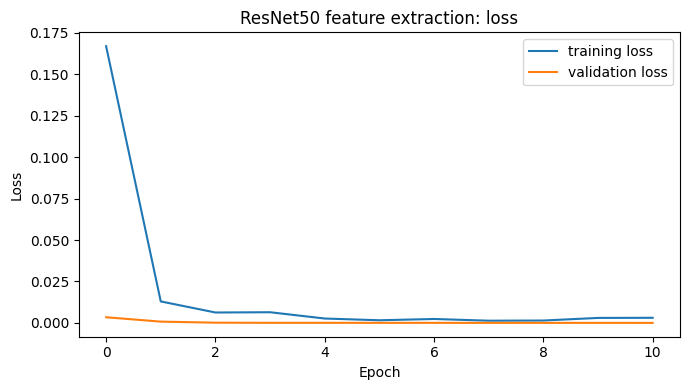

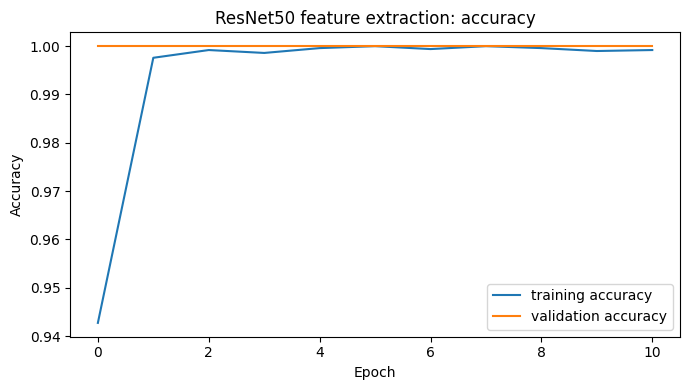


Classification report for ResNet50 Transfer Learning
              precision    recall  f1-score   support

      Banana     0.0000    0.0000    0.0000         0
      Cherry     0.0000    0.0000    0.0000         0
       Grape     0.0000    0.0000    0.0000         0
       Mango     1.0000    1.0000    1.0000        26
       Peach     1.0000    1.0000    1.0000      1222

    accuracy                         1.0000      1248
   macro avg     0.4000    0.4000    0.4000      1248
weighted avg     1.0000    1.0000    1.0000      1248



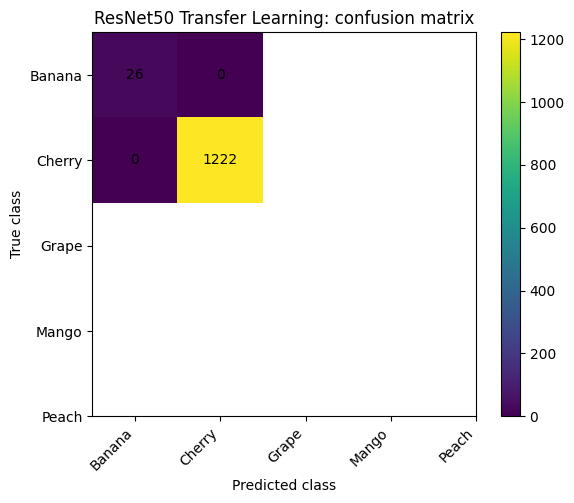

In [ ]:
resnet_start = time.time()
resnet_history = resnet_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=12,
    callbacks=[fresh_early_stop(patience_value=3)],
    verbose=1
)
resnet_seconds = show_runtime(resnet_start, 'ResNet50 feature extraction')

draw_learning_curves(resnet_history, 'ResNet50 feature extraction')
_ = evaluate_classifier(resnet_model, transfer_val_ds, class_names, 'ResNet50 Transfer Learning', resnet_seconds)

In [ ]:
mobilenet_model, mobilenet_base = create_transfer_model('MobileNetV2', number_of_classes)
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_fruit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_fruit_augmentation_pi… │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.9427 - loss: 0.1676 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9948 - loss: 0.0191 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9978 - loss: 0.0100 - val_accuracy: 1.0000 - val_loss: 7.8691e-04
Epoch 4/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9986 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 6.0287e-04
Epoch 5/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9980 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 1.7145e-04
Epoch 6/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.9982 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 8.8421e-04
Epoch 7/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 2.0177e-04
Epoch 8/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.99

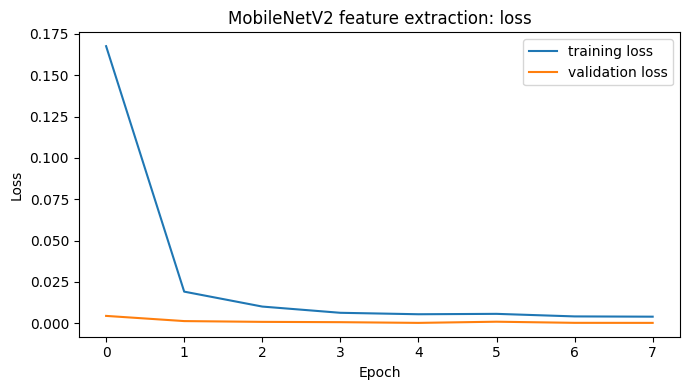

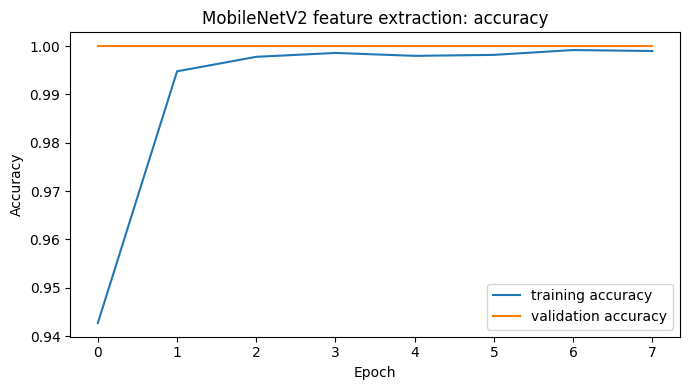


Classification report for MobileNetV2 Transfer Learning
              precision    recall  f1-score   support

      Banana     0.0000    0.0000    0.0000         0
      Cherry     0.0000    0.0000    0.0000         0
       Grape     0.0000    0.0000    0.0000         0
       Mango     1.0000    1.0000    1.0000        26
       Peach     1.0000    1.0000    1.0000      1222

    accuracy                         1.0000      1248
   macro avg     0.4000    0.4000    0.4000      1248
weighted avg     1.0000    1.0000    1.0000      1248



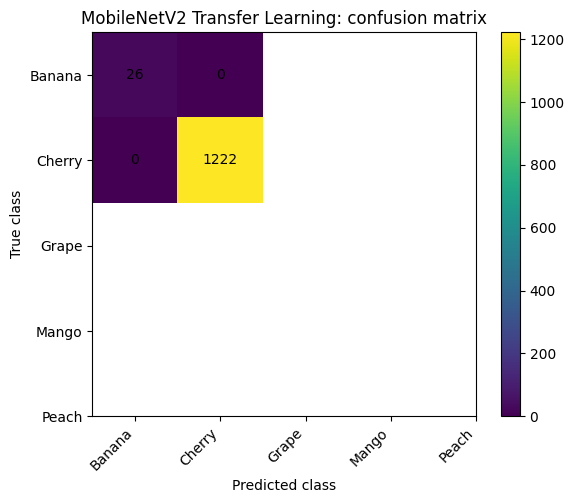

In [ ]:
mobilenet_start = time.time()
mobilenet_history = mobilenet_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=12,
    callbacks=[fresh_early_stop(patience_value=3)],
    verbose=1
)
mobilenet_seconds = show_runtime(mobilenet_start, 'MobileNetV2 feature extraction')

draw_learning_curves(mobilenet_history, 'MobileNetV2 feature extraction')
_ = evaluate_classifier(mobilenet_model, transfer_val_ds, class_names, 'MobileNetV2 Transfer Learning', mobilenet_seconds)

## 11. Prediction on unlabelled test images

The dataset also includes a `Test` folder without class subfolders. The following helper loads a few test images and displays the model's predicted fruit label.


In [ ]:
def predict_unlabelled_folder(model_object, folder_path, label_names, image_size, max_images=12):
    folder_path = Path(folder_path)
    test_files = sorted([p for p in folder_path.iterdir() if p.is_file()])[:max_images]
    if not test_files:
        print('No unlabelled test images found.')
        return

    plt.figure(figsize=(12, 8))
    for i, image_path in enumerate(test_files):
        img = keras.utils.load_img(image_path, target_size=image_size)
        arr = keras.utils.img_to_array(img)
        batch = np.expand_dims(arr, axis=0)
        probs = model_object.predict(batch, verbose=0)[0]
        pred_label = label_names[int(np.argmax(probs))]
        confidence = float(np.max(probs))

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f'{pred_label}\n{confidence:.2%}')
        plt.axis('off')
    plt.suptitle('Predictions on unlabelled test images')
    plt.tight_layout()
    plt.show()

# Choose the best-performing trained model before running this cell.
# predict_unlabelled_folder(mobilenet_model, UNLABELLED_TEST_DIR, class_names, TRANSFER_IMAGE_SIZE)

## 12. Final comparison and interpretation

The table below gathers the validation loss, validation accuracy, and training time recorded by the shared evaluation helper. Use it to discuss whether the deeper CNN improved on the baseline, whether SGD or Adam converged faster, how the ablation changed validation performance, and whether transfer learning outperformed training from scratch.


In [ ]:
final_results = pd.DataFrame(experiment_records)
final_results.sort_values('validation_accuracy', ascending=False).reset_index(drop=True)

,model,validation_loss,validation_accuracy,training_seconds
0,Baseline CNN,6.982527e-08,1.0,45.420680
1,Regularised Deeper CNN,4.974997e-04,1.0,128.605268
2,Deeper CNN + SGD,1.273885e-04,1.0,99.201752
3,Ablated Deeper CNN,1.489361e-04,1.0,96.106014
4,ResNet50 Transfer Learning,4.299202e-06,1.0,316.235609
5,MobileNetV2 Transfer Learning,1.714479e-04,1.0,105.993456


## 13. Key observations to write in the report

- The baseline CNN provides a simple reference point with three convolutional blocks and three dense layers.
- The deeper model has greater representational capacity, but the validation curves should be checked for overfitting.
- The optimizer comparison tests convergence behaviour under SGD with momentum versus Adam.
- The ablation experiment shows the effect of removing dropout and batch normalization.
- ResNet50 and MobileNetV2 use ImageNet features, so they may reach strong validation accuracy with fewer epochs than CNNs trained from scratch.
- MobileNetV2 is usually more efficient, while ResNet50 is deeper and may extract stronger high-level features depending on the dataset.

When preparing the final report, include the actual values produced after running the notebook: total images, class counts, validation accuracy, validation loss, per-class F1-score, training time, and comments on failure cases.
